In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, RandomizedSearchCV

from catboost import CatBoostRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("../stud.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.shape

(1000, 8)

In [6]:
df.columns


Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [8]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [3]:
import os
os.getcwd()

'c:\\Users\\Admin\\mlproject\\notebook'

In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [11]:
print("Gender:", df["gender"].unique())
print("Race/Ethnicity:", df["race_ethnicity"].unique())
print("Parental Education:", df["parental_level_of_education"].unique())
print("Lunch:", df["lunch"].unique())
print("Test Preparation:", df["test_preparation_course"].unique())

Gender: <StringArray>
['female', 'male']
Length: 2, dtype: str
Race/Ethnicity: <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Parental Education: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Lunch: <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Test Preparation: <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [12]:
df[["math_score", "reading_score", "writing_score"]].mean()

math_score       66.089
reading_score    69.169
writing_score    68.054
dtype: float64

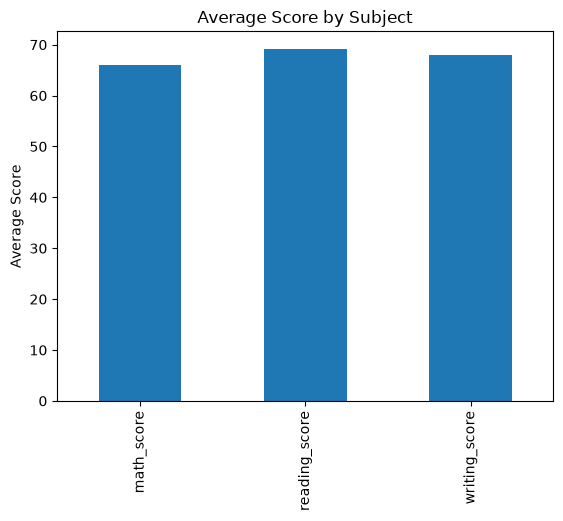

In [13]:
df[["math_score", "reading_score", "writing_score"]].mean().plot(
    kind="bar",
    title="Average Score by Subject"
)

plt.ylabel("Average Score")
plt.show()

In [14]:
df["total_score"] = (
    df["math_score"]
    + df["reading_score"]
    + df["writing_score"]
)

df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [15]:
df["total_score"].mean()

np.float64(203.312)

In [16]:
df[["math_score", "reading_score", "writing_score"]].corr()

,math_score,reading_score,writing_score
math_score,1.000000,0.817580,0.802642
reading_score,0.817580,1.000000,0.954598
writing_score,0.802642,0.954598,1.000000


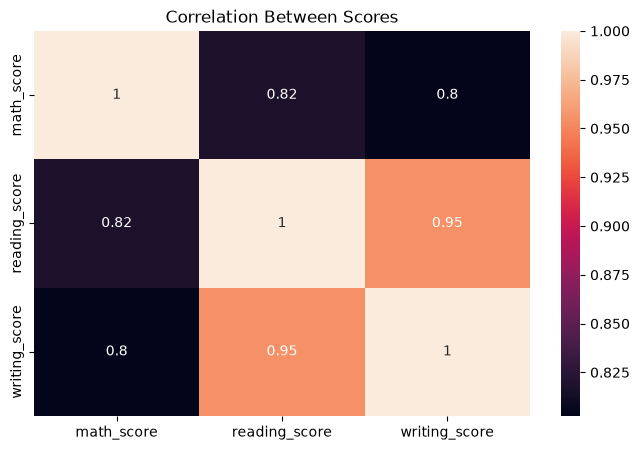

In [17]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df[["math_score", "reading_score", "writing_score"]].corr(),
    annot=True
)

plt.title("Correlation Between Scores")
plt.show()

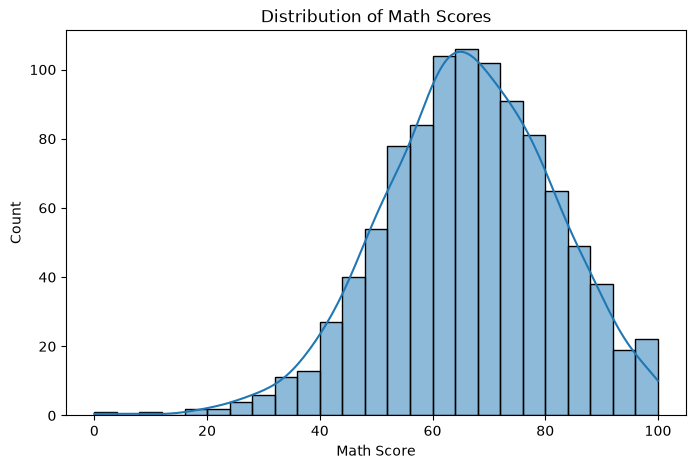

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(df["math_score"], kde=True)

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.show()

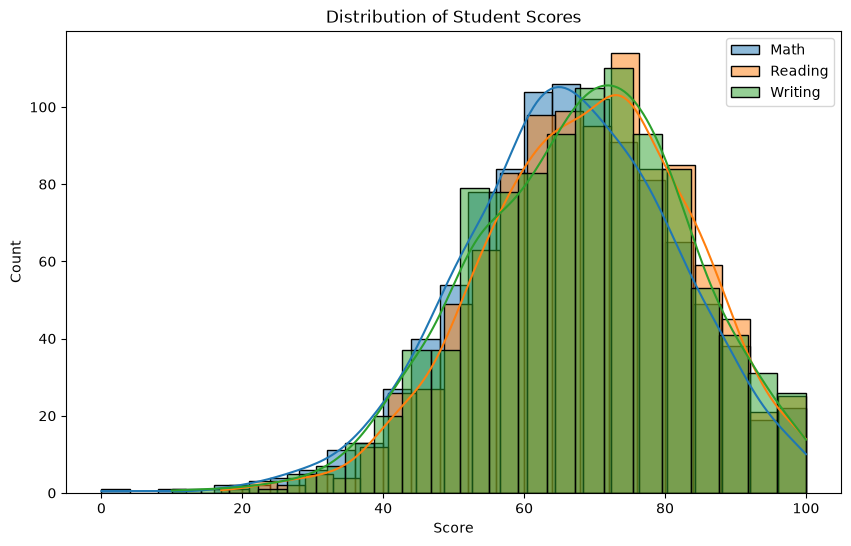

In [19]:
plt.figure(figsize=(10, 6))

sns.histplot(df["math_score"], kde=True, label="Math", alpha=0.5)
sns.histplot(df["reading_score"], kde=True, label="Reading", alpha=0.5)
sns.histplot(df["writing_score"], kde=True, label="Writing", alpha=0.5)

plt.title("Distribution of Student Scores")
plt.xlabel("Score")
plt.legend()
plt.show()

In [20]:
df.groupby("test_preparation_course")[
    ["math_score", "reading_score", "writing_score"]
].mean()

,math_score,reading_score,writing_score
test_preparation_course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


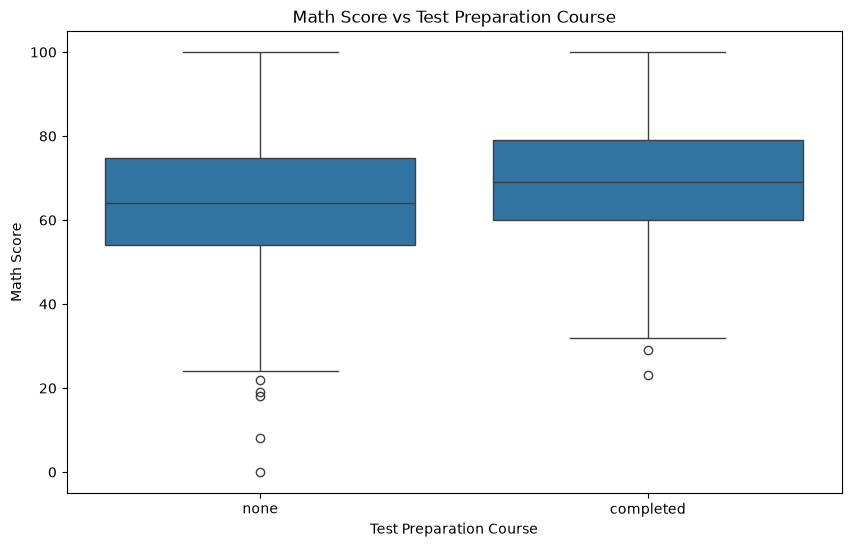

In [21]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="test_preparation_course",
    y="math_score",
    data=df
)

plt.title("Math Score vs Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Math Score")
plt.show()

In [22]:
df.groupby("parental_level_of_education")[
    ["math_score", "reading_score", "writing_score"]
].mean().sort_values("math_score", ascending=False)

,math_score,reading_score,writing_score
parental_level_of_education,,,
master's degree,69.745763,75.372881,75.677966
bachelor's degree,69.389831,73.000000,73.381356
associate's degree,67.882883,70.927928,69.896396
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268
high school,62.137755,64.704082,62.448980


In [23]:
df.groupby("lunch")[
    ["math_score", "reading_score", "writing_score"]
].mean()

,math_score,reading_score,writing_score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


In [24]:
df.groupby("gender")[
    ["math_score", "reading_score", "writing_score"]
].mean()


,math_score,reading_score,writing_score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [25]:
df[["math_score", "reading_score", "writing_score", "total_score"]].describe()


,math_score,reading_score,writing_score,total_score
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,203.312000
std,15.16308,14.600192,15.195657,42.771978
min,0.00000,17.000000,10.000000,27.000000
25%,57.00000,59.000000,57.750000,175.000000
50%,66.00000,70.000000,69.000000,205.000000
75%,77.00000,79.000000,79.000000,233.000000
max,100.00000,100.000000,100.000000,300.000000


In [28]:
X = df.drop("math_score", axis=1)
y = df["math_score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 8)
y shape: (1000,)


In [29]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='str')

Numerical columns:
Index(['reading_score', 'writing_score', 'total_score'], dtype='str')


In [30]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_encoded = encoder.fit_transform(X[categorical_cols])

X_encoded = pd.DataFrame(
    X_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X.index
)

X_encoded.head()

,gender_female,gender_male,race_ethnicity_group A,race_ethnicity_group B,race_ethnicity_group C,race_ethnicity_group D,race_ethnicity_group E,parental_level_of_education_associate's degree,parental_level_of_education_bachelor's degree,parental_level_of_education_high school,parental_level_of_education_master's degree,parental_level_of_education_some college,parental_level_of_education_some high school,lunch_free/reduced,lunch_standard,test_preparation_course_completed,test_preparation_course_none
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


In [31]:
X_final = pd.concat(
    [
        X[numerical_cols].reset_index(drop=True),
        X_encoded.reset_index(drop=True)
    ],
    axis=1
)

X_final.head()

,reading_score,writing_score,total_score,gender_female,gender_male,race_ethnicity_group A,race_ethnicity_group B,race_ethnicity_group C,race_ethnicity_group D,race_ethnicity_group E,parental_level_of_education_associate's degree,parental_level_of_education_bachelor's degree,parental_level_of_education_high school,parental_level_of_education_master's degree,parental_level_of_education_some college,parental_level_of_education_some high school,lunch_free/reduced,lunch_standard,test_preparation_course_completed,test_preparation_course_none
0,72,74,218,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,90,88,247,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,95,93,278,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,57,44,148,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,78,75,229,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 20)
X_test: (200, 20)
y_train: (800,)
y_test: (200,)


In [33]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 7.206561747707768e-14
MSE : 7.362077772453364e-27
RMSE: 8.580255108359753e-14
R2  : 1.0


In [35]:
X = df.drop(["math_score", "total_score"], axis=1)
y = df["math_score"]

categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

print("Features:", X.columns.tolist())

Features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'reading_score', 'writing_score']


In [36]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_encoded = encoder.fit_transform(X[categorical_cols])

X_encoded = pd.DataFrame(
    X_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X.index
)

X_final = pd.concat(
    [
        X[numerical_cols].reset_index(drop=True),
        X_encoded.reset_index(drop=True)
    ],
    axis=1
)

print("Final feature shape:", X_final.shape)

Final feature shape: (1000, 19)


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 19)
X_test: (200, 19)
y_train: (800,)
y_test: (200,)


In [38]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


In [39]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 4.214763142474851
MSE : 29.095169866715466
RMSE: 5.3939938697328405
R2  : 0.8804332983749565


In [40]:
model_dt = DecisionTreeRegressor(random_state=42)

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

print("Decision Tree trained successfully!")


Decision Tree trained successfully!


In [41]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R2  :", r2_dt)

MAE : 6.24
MSE : 61.48
RMSE: 7.840918313565063
R2  : 0.7473477264582984


In [42]:
model_rf = RandomForestRegressor(random_state=42)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [43]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

MAE : 4.706316666666667
MSE : 36.47899359084467
RMSE: 6.039784233798809
R2  : 0.8500894491340263


In [44]:
model_knn = KNeighborsRegressor()

model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

print("KNN trained successfully!")

KNN trained successfully!


In [45]:
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("MAE :", mae_knn)
print("MSE :", mse_knn)
print("RMSE:", rmse_knn)
print("R2  :", r2_knn)

MAE : 6.289
MSE : 64.4514
RMSE: 8.028162928092579
R2  : 0.7351367478375792


In [46]:
model_svr = SVR()

model_svr.fit(X_train, y_train)

y_pred_svr = model_svr.predict(X_test)

print("SVR trained successfully!")

SVR trained successfully!


In [47]:
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("MAE :", mae_svr)
print("MSE :", mse_svr)
print("RMSE:", rmse_svr)
print("R2  :", r2_svr)

MAE : 7.710236382103788
MSE : 91.62920159045024
RMSE: 9.572314327812801
R2  : 0.6234494778035434


In [48]:
model_ada = AdaBoostRegressor(random_state=42)

model_ada.fit(X_train, y_train)

y_pred_ada = model_ada.predict(X_test)

print("AdaBoost trained successfully!")

AdaBoost trained successfully!


In [49]:
mae_ada = mean_absolute_error(y_test, y_pred_ada)
mse_ada = mean_squared_error(y_test, y_pred_ada)
rmse_ada = np.sqrt(mse_ada)
r2_ada = r2_score(y_test, y_pred_ada)

print("MAE :", mae_ada)
print("MSE :", mse_ada)
print("RMSE:", rmse_ada)
print("R2  :", r2_ada)

MAE : 4.7211104192667195
MSE : 36.704503868420915
RMSE: 6.058424206707625
R2  : 0.84916271386505


In [50]:
model_ridge = Ridge()

model_ridge.fit(X_train, y_train)

y_pred_ridge = model_ridge.predict(X_test)

print("Ridge trained successfully!")

Ridge trained successfully!


In [51]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("MAE :", mae_ridge)
print("MSE :", mse_ridge)
print("RMSE:", rmse_ridge)
print("R2  :", r2_ridge)


MAE : 4.212841100014788
MSE : 29.087433472118143
RMSE: 5.393276691596505
R2  : 0.8804650911154255


In [52]:
model_lasso = Lasso()

model_lasso.fit(X_train, y_train)

y_pred_lasso = model_lasso.predict(X_test)

print("Lasso trained successfully!")

Lasso trained successfully!


In [53]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("MAE :", mae_lasso)
print("MSE :", mse_lasso)
print("RMSE:", rmse_lasso)
print("R2  :", r2_lasso)

MAE : 5.0170362180465675
MSE : 40.49070178244291
RMSE: 6.363230451778634
R2  : 0.8336033203865773


In [54]:
model_cat = CatBoostRegressor(verbose=False, random_state=42)

model_cat.fit(X_train, y_train)

y_pred_cat = model_cat.predict(X_test)

print("CatBoost trained successfully!")

CatBoost trained successfully!


In [55]:
mae_cat = mean_absolute_error(y_test, y_pred_cat)
mse_cat = mean_squared_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
r2_cat = r2_score(y_test, y_pred_cat)

print("MAE :", mae_cat)
print("MSE :", mse_cat)
print("RMSE:", rmse_cat)
print("R2  :", r2_cat)

MAE : 4.589369375065306
MSE : 36.40091975522346
RMSE: 6.033317475089759
R2  : 0.8504102938326895


In [56]:
model_xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [57]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("MAE :", mae_xgb)
print("MSE :", mse_xgb)
print("RMSE:", rmse_xgb)
print("R2  :", r2_xgb)

MAE : 5.1036295890808105
MSE : 43.50392150878906
RMSE: 6.595750261250729
R2  : 0.8212205171585083


In [58]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring="r2"
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R2:", grid_search.best_score_)

Best parameters: {'alpha': 1}
Best CV R2: 0.8686199688095668


In [59]:
best_ridge = Ridge(alpha=1)

best_ridge.fit(X_train, y_train)

y_pred_best = best_ridge.predict(X_test)

print("Tuned Ridge model trained successfully!")

Tuned Ridge model trained successfully!


In [60]:
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print("MAE :", mae_best)
print("MSE :", mse_best)
print("RMSE:", rmse_best)
print("R2  :", r2_best)

MAE : 4.212841100014788
MSE : 29.087433472118143
RMSE: 5.393276691596505
R2  : 0.8804650911154255


In [61]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVR",
        "AdaBoost",
        "CatBoost",
        "XGBoost"
    ],
    "MAE": [
        4.214763142474851,
        4.212841100014788,
        5.0170362180465675,
        6.24,
        4.706316666666667,
        6.289,
        7.710236382103788,
        4.7211104192667195,
        4.589369375065306,
        5.1036295890808105
    ],
    "RMSE": [
        5.3939938697328405,
        5.393276691596505,
        6.363230451778634,
        7.840918313565063,
        6.039784233798809,
        8.028162928092579,
        9.572314327812801,
        6.058424206707625,
        6.033317475089759,
        6.595750261250729
    ],
    "R2": [
        0.8804332983749565,
        0.8804650911154255,
        0.8336033203865773,
        0.7473477264582984,
        0.8500894491340263,
        0.7351367478375792,
        0.6234494778035434,
        0.84916271386505,
        0.8504102938326895,
        0.8212205171585083
    ]
})

results.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
1,Ridge,4.212841,5.393277,0.880465
0,Linear Regression,4.214763,5.393994,0.880433
8,CatBoost,4.589369,6.033317,0.850410
4,Random Forest,4.706317,6.039784,0.850089
7,AdaBoost,4.721110,6.058424,0.849163
2,Lasso,5.017036,6.363230,0.833603
9,XGBoost,5.103630,6.595750,0.821221
3,Decision Tree,6.240000,7.840918,0.747348
5,KNN,6.289000,8.028163,0.735137
6,SVR,7.710236,9.572314,0.623449
